# 03 — Pressure-Level Atmospheric Structure
## จากแผนที่ 2 มิติ สู่โครงสร้างบรรยากาศในแนวดิ่ง

**กลุ่มผู้เรียน:** นิสิตปริญญาตรีชั้นปีที่ 3–4 ด้านสิ่งแวดล้อม ภูมิศาสตร์ และภูมิสารสนเทศ  
**Platform:** Google Colab + Google Drive  
**ข้อมูลหลัก:** ERA5 EVENT teaching dataset  
**บทก่อนหน้า:** Notebook 02 — Spatial Subsetting, Cartopy and Map Projections

Notebook นี้พานิสิตจากการดู field บนแผนที่เพียงระดับเดียว ไปสู่การมองบรรยากาศแบบสามมิติ

```text
pressure level คืออะไร?
        ↓
pressure ลดลงกับความสูงอย่างไร?
        ↓
1000 / 850 / 700 / 500 / 300 / 200 hPa
แทนส่วนใดของบรรยากาศ?
        ↓
temperature และ moisture เปลี่ยนตามระดับอย่างไร?
        ↓
geopotential height คืออะไร?
        ↓
vertical profile อ่านอย่างไร?
```

แนวคิดสำคัญ:

> **Pressure level เป็นพื้นผิวสามมิติในบรรยากาศ ไม่ใช่ความสูงคงที่จากระดับน้ำทะเล**

# Learning Objectives

เมื่อจบบทนี้ นิสิตควรสามารถ:

1. อธิบาย pressure coordinate และ pressure level
2. อธิบาย hydrostatic balance
3. อธิบายว่าทำไม pressure ลดลงเมื่อสูงขึ้น
4. อธิบาย hypsometric equation เชิงกายภาพ
5. แปลง geopotential เป็น geopotential height
6. แปลง temperature จาก K เป็น °C
7. แปลง specific humidity จาก kg kg⁻¹ เป็น g kg⁻¹
8. สร้าง multi-level maps ของ temperature และ relative humidity
9. สร้าง geopotential-height maps
10. สกัด vertical profile ณ ตำแหน่งทางภูมิศาสตร์
11. คำนวณ potential temperature
12. อธิบายข้อจำกัดของ low-level pressure fields เหนือภูเขาสูง
13. export vertical-profile tables และ figures

# 1. Pressure เป็น Vertical Coordinate

ในบรรยากาศ pressure ลดลงเมื่อสูงขึ้น

```text
ใกล้พื้น
→ pressure สูง

สูงขึ้น
→ pressure ลดลง
```

EVENT dataset มี pressure levels:

```text
1000, 925, 850, 700, 500, 300, 250, 200 hPa
```

pressure level ไม่ได้หมายถึงความสูงคงที่ทุกตำแหน่งบนโลก

# 2. Hydrostatic Balance

สมการพื้นฐานคือ:

$$
\frac{dp}{dz}
=
-\rho g
$$

โดย:

- $p$ = pressure
- $z$ = height
- $\rho$ = air density
- $g$ = gravitational acceleration

เครื่องหมายลบหมายถึง pressure ลดลงเมื่อ height เพิ่มขึ้น

# 3. Ideal Gas Law

อากาศแห้งโดยประมาณเป็น ideal gas:

$$
p
=
\rho R_d T
$$

โดย $R_d \approx 287.05\ \mathrm{J\,kg^{-1}\,K^{-1}}$

เมื่อนำ Ideal Gas Law รวมกับ Hydrostatic Equation จะเชื่อม pressure, temperature และความหนาของชั้นบรรยากาศเข้าด้วยกัน

# 4. Hypsometric Equation

ความหนาระหว่าง pressure surfaces สองระดับประมาณได้จาก:

$$
z_2-z_1
=
\frac{R_d\overline{T_v}}{g}
\ln
\left(
\frac{p_1}{p_2}
\right)
$$

ข้อสรุปสำคัญ:

> **ชั้นบรรยากาศที่อุ่นกว่าจะมีความหนาระหว่าง pressure surfaces มากกว่า**

# 5. Geopotential และ Geopotential Height

ERA5 variable `z` คือ **geopotential** มีหน่วย `m² s⁻²`

$$
\Phi
=
\int_0^z g\,dz
$$

Geopotential height คือ:

$$
H
=
\frac{\Phi}{g_0}
$$

โดย:

$$
g_0
=
9.80665\ \mathrm{m\,s^{-2}}
$$

ดังนั้น:

```text
ERA5 z
≠ geopotential height in metres directly
```

# 6. Temperature และ Moisture

Temperature:

$$
T_{^\circ C}
=
T_K-273.15
$$

Specific humidity:

$$
q
=
\frac{m_v}{m_d+m_v}
$$

เพื่อให้อ่านง่าย:

$$
q_{\mathrm{g/kg}}
=
1000q_{\mathrm{kg/kg}}
$$

Relative humidity `r` ใช้หน่วย % และไม่เท่ากับ water-vapor mass โดยตรง

# 7. Potential Temperature

Potential temperature คือ temperature ที่ air parcel จะมีหากนำไปยัง 1000 hPa แบบ dry adiabatic

$$
\theta
=
T
\left(
\frac{p_0}{p}
\right)^\kappa
$$

โดย:

$$
p_0=1000\ \mathrm{hPa}
$$

และ:

$$
\kappa
=
\frac{R_d}{c_p}
\approx
0.286
$$

โดยทั่วไป $\theta$ ที่เพิ่มขึ้นตามความสูงสัมพันธ์กับ stable stratification แต่ pressure levels ในชุดนี้ค่อนข้างหยาบ จึงไม่ควรใช้แทน high-resolution sounding

# 8. Pressure-Level Orientation

| Pressure | Atmospheric role โดยประมาณ |
|---|---|
| 1000 hPa | Near sea-level atmosphere |
| 925 hPa | Very low level |
| 850 hPa | Lower troposphere |
| 700 hPa | Lower–mid troposphere |
| 500 hPa | Mid-troposphere |
| 300 hPa | Upper troposphere |
| 250 hPa | Upper-level flow / jet region |
| 200 hPa | Upper troposphere |

นี่เป็นเพียง orientation เพราะความสูงจริงของ pressure surface เปลี่ยนตามสภาพบรรยากาศ

# 9. ข้อควรระวังเหนือภูเขาสูง

pressure surfaces ระดับล่าง เช่น 1000, 925 หรือ 850 hPa อาจอยู่ต่ำกว่าพื้นดินในบริเวณภูเขาสูง

Teaching EVENT dataset ไม่มี surface pressure สำหรับสร้าง below-ground mask แบบสมบูรณ์

> **จึงต้องตีความ low-level pressure fields เหนือภูเขาสูงอย่างระมัดระวัง**

# 10. ติดตั้งไลบรารี

In [1]:
# CELL 1 — Install/check libraries

import sys
import subprocess

PACKAGES = [
    'xarray>=2025.1',
    'netCDF4>=1.7',
    'h5netcdf>=1.4',
    'dask[array]>=2025.1',
    'numpy>=1.26',
    'pandas>=2.2',
    'matplotlib>=3.8',
    'cartopy>=0.23',
]

subprocess.check_call(
    [
        sys.executable,
        '-m',
        'pip',
        'install',
        '-q',
        '--upgrade-strategy',
        'only-if-needed',
        *PACKAGES,
    ]
)

print('Libraries ready.')

Libraries ready.


# 11. Mount Google Drive

In [2]:
# CELL 2 — Mount Google Drive

from pathlib import Path
from google.colab import drive

drive.mount(
    '/content/drive',
    force_remount=False,
)

DRIVE_ROOT = Path('/content/drive/MyDrive')

print('Google Drive mounted:', DRIVE_ROOT)

Mounted at /content/drive
Google Drive mounted: /content/drive/MyDrive


# 12. Import libraries

In [3]:
# CELL 3 — Imports

from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from IPython.display import display

G0 = 9.80665
RD = 287.05
CP = 1004.0
KAPPA = RD / CP

print('Python:', sys.version.split()[0])
print('NumPy:', np.__version__)
print('pandas:', pd.__version__)
print('Xarray:', xr.__version__)
print('kappa:', KAPPA)

Python: 3.13.15
NumPy: 2.1.3
pandas: 2.2.3
Xarray: 2025.12.0
kappa: 0.285906374501992


# 13. Course paths

In [4]:
# CELL 4 — Course paths

COURSE_ROOT = (
    DRIVE_ROOT
    / 'Teaching_ERA5_Reanalysis_GIS'
)

SOURCE_GITHUB_DIR = (
    COURSE_ROOT
    / '00_source_github'
)

METADATA_DIR = (
    COURSE_ROOT
    / '02_metadata'
)

OUTPUT_DIR = (
    COURSE_ROOT
    / '03_output'
)

FIGURE_DIR = (
    COURSE_ROOT
    / '04_figures'
    / '03'
)

for folder in [
    METADATA_DIR,
    OUTPUT_DIR,
    FIGURE_DIR,
]:
    folder.mkdir(
        parents=True,
        exist_ok=True,
    )

EVENT_FILE = (
    SOURCE_GITHUB_DIR
    / 'era5_noul_20111002_05_SEAsia_pressure_levels_0.5deg.nc'
)

if not EVENT_FILE.exists():
    raise FileNotFoundError(
        'EVENT teaching dataset not found. Run Notebook 00 first.'
    )

print('EVENT file:', EVENT_FILE)

EVENT file: /content/drive/MyDrive/Teaching_ERA5_Reanalysis_GIS/00_source_github/era5_noul_20111002_05_SEAsia_pressure_levels_0.5deg.nc


# 14. เปิด EVENT dataset

In [5]:
# CELL 5 — Open EVENT dataset

ds = xr.open_dataset(
    EVENT_FILE,
    decode_times=True,
)

print(ds)

<xarray.Dataset> Size: 14MB
Dimensions:    (time: 4, level: 8, latitude: 100, longitude: 140)
Coordinates:
  * time       (time) datetime64[ns] 32B 2011-10-02 2011-10-03 ... 2011-10-05
  * level      (level) int32 32B 200 250 300 500 700 850 925 1000
  * latitude   (latitude) float32 400B 44.88 44.38 43.88 ... -4.125 -4.625
  * longitude  (longitude) float32 560B 60.12 60.62 61.12 ... 128.6 129.1 129.6
Data variables:
    d          (time, level, latitude, longitude) float32 2MB ...
    z          (time, level, latitude, longitude) float32 2MB ...
    r          (time, level, latitude, longitude) float32 2MB ...
    q          (time, level, latitude, longitude) float32 2MB ...
    t          (time, level, latitude, longitude) float32 2MB ...
    u          (time, level, latitude, longitude) float32 2MB ...
    v          (time, level, latitude, longitude) float32 2MB ...
    vo         (time, level, latitude, longitude) float32 2MB ...
Attributes: (12/17)
    Conventions:              

# 15. ตรวจ Pressure Levels และ Variables

In [6]:
# CELL 6 — Pressure-level and variable audit

PRESSURE_LEVELS = np.asarray(
    ds['level'].values,
    dtype=float,
)

PRESSURE_LEVEL_AUDIT = pd.DataFrame(
    {
        'pressure_hPa': PRESSURE_LEVELS,
        'available': True,
    }
)

display(PRESSURE_LEVEL_AUDIT)

print('Variables:', list(ds.data_vars))

,pressure_hPa,available
0,200.0,True
1,250.0,True
2,300.0,True
3,500.0,True
4,700.0,True
5,850.0,True
6,925.0,True
7,1000.0,True


Variables: ['d', 'z', 'r', 'q', 't', 'u', 'v', 'vo']


# 16. เลือกเวลาอ้างอิง

In [7]:
# CELL 7 — Reference event time

REFERENCE_TIME = pd.Timestamp(
    '2011-10-02 00:00:00'
)

available_times = pd.DatetimeIndex(
    pd.to_datetime(
        ds['time'].values
    )
)

if REFERENCE_TIME not in available_times:
    raise ValueError(
        f'Reference time not found: {REFERENCE_TIME}'
    )

print('Reference time:', REFERENCE_TIME)

Reference time: 2011-10-02 00:00:00


# 17. สร้าง Derived Variables

In [8]:
# CELL 8 — Derived atmospheric variables

event = ds.sel(
    time=REFERENCE_TIME
)

temperature_C = (
    event['t']
    - 273.15
)

temperature_C.name = 'temperature_C'
temperature_C.attrs.update(
    {
        'long_name': 'Air temperature',
        'units': 'degC',
    }
)

geopotential_height_m = (
    event['z']
    / G0
)

geopotential_height_m.name = 'geopotential_height_m'
geopotential_height_m.attrs.update(
    {
        'long_name': 'Geopotential height',
        'units': 'm',
    }
)

specific_humidity_gkg = (
    event['q']
    * 1000.0
)

specific_humidity_gkg.name = 'specific_humidity_gkg'
specific_humidity_gkg.attrs.update(
    {
        'long_name': 'Specific humidity',
        'units': 'g kg-1',
    }
)

pressure_1d = xr.DataArray(
    event['level'].values,
    coords={'level': event['level']},
    dims=['level'],
)

potential_temperature_K = (
    event['t']
    * (
        1000.0
        / pressure_1d
    ) ** KAPPA
)

potential_temperature_K.name = 'potential_temperature_K'
potential_temperature_K.attrs.update(
    {
        'long_name': 'Potential temperature',
        'units': 'K',
    }
)

print('Derived variables ready.')

Derived variables ready.


# 18. กำหนด Analysis Domain

In [9]:
# CELL 9 — Regional analysis domain

ANALYSIS_DOMAIN = {
    'lon_min': 80.0,
    'lon_max': 130.0,
    'lat_min': 0.0,
    'lat_max': 35.0,
}

print(ANALYSIS_DOMAIN)

{'lon_min': 80.0, 'lon_max': 130.0, 'lat_min': 0.0, 'lat_max': 35.0}


In [10]:
# CELL 10 — Coordinate-aware spatial subset helper

def coordinate_slice(
    coordinate,
    lower,
    upper,
):
    values = np.asarray(
        coordinate.values
    )

    if values[-1] > values[0]:
        return slice(lower, upper)

    return slice(upper, lower)


def subset_domain(
    data_array,
    domain,
):
    subset = data_array.sel(
        latitude=coordinate_slice(
            data_array['latitude'],
            domain['lat_min'],
            domain['lat_max'],
        ),
        longitude=coordinate_slice(
            data_array['longitude'],
            domain['lon_min'],
            domain['lon_max'],
        ),
    )

    if (
        subset.sizes['latitude'] == 0
        or subset.sizes['longitude'] == 0
    ):
        raise ValueError('Spatial subset is empty.')

    return subset

In [11]:
# CELL 11 — Base map helper

def decorate_map(
    ax,
    *,
    extent,
):
    ax.coastlines(
        resolution='110m',
        linewidth=0.7,
    )

    ax.add_feature(
        cfeature.BORDERS,
        linewidth=0.5,
    )

    ax.set_extent(
        extent,
        crs=ccrs.PlateCarree(),
    )

    gl = ax.gridlines(
        draw_labels=True,
        linewidth=0.35,
        alpha=0.45,
        linestyle='--',
    )

    gl.top_labels = False
    gl.right_labels = False

    return ax

# 19. Figure 03-1 — Multi-Level Temperature Structure

เราจะเปรียบเทียบ temperature ที่ 1000, 850, 700, 500, 300 และ 200 hPa โดยใช้ common color scale ทุก panel

สิ่งนี้ช่วยให้นิสิตเห็น vertical temperature contrast โดยตรง

/usr/local/lib/python3.13/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.13/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


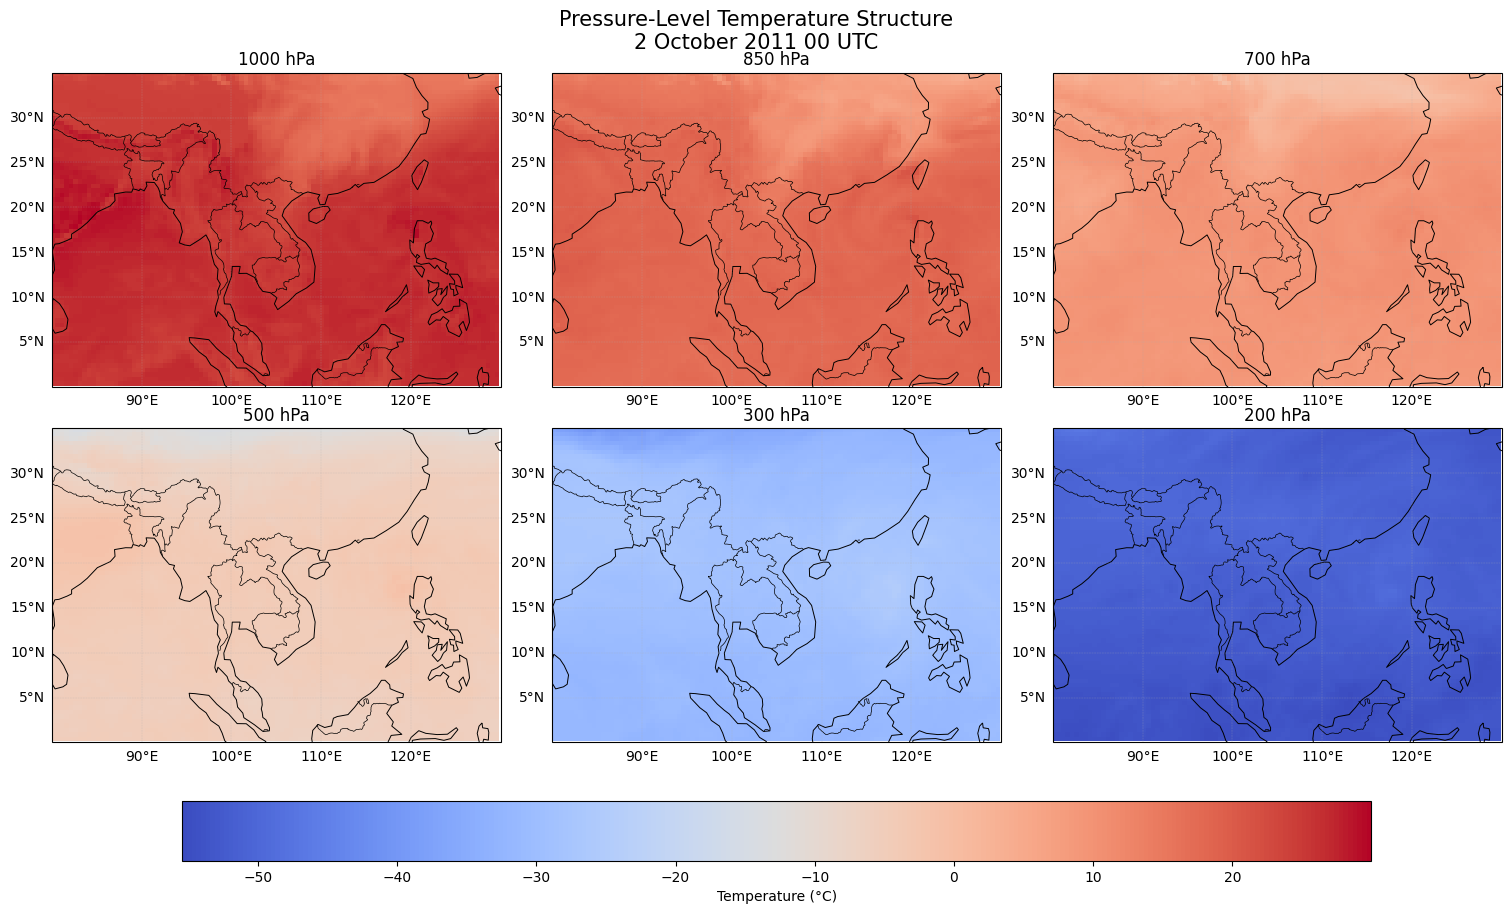

Saved: /content/drive/MyDrive/Teaching_ERA5_Reanalysis_GIS/04_figures/03/03_01_multilevel_temperature_structure.png


In [12]:
# CELL 12 — Multi-level temperature maps

TEMP_LEVELS = [
    1000,
    850,
    700,
    500,
    300,
    200,
]

temp_fields = [
    subset_domain(
        temperature_C.sel(level=level),
        ANALYSIS_DOMAIN,
    )
    for level in TEMP_LEVELS
]

temp_vmin = min(
    float(field.min().values)
    for field in temp_fields
)

temp_vmax = max(
    float(field.max().values)
    for field in temp_fields
)

fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(15, 9),
    subplot_kw={
        'projection': ccrs.PlateCarree()
    },
    constrained_layout=True,
)

axes = axes.ravel()

for ax, level, field in zip(
    axes,
    TEMP_LEVELS,
    temp_fields,
):
    mesh = ax.pcolormesh(
        field['longitude'],
        field['latitude'],
        field,
        transform=ccrs.PlateCarree(),
        shading='auto',
        cmap='coolwarm',
        vmin=temp_vmin,
        vmax=temp_vmax,
    )

    decorate_map(
        ax,
        extent=[
            ANALYSIS_DOMAIN['lon_min'],
            ANALYSIS_DOMAIN['lon_max'],
            ANALYSIS_DOMAIN['lat_min'],
            ANALYSIS_DOMAIN['lat_max'],
        ],
    )

    ax.set_title(
        f'{level} hPa'
    )

cbar = fig.colorbar(
    mesh,
    ax=axes.tolist(),
    orientation='horizontal',
    pad=0.05,
    shrink=0.82,
)

cbar.set_label('Temperature (°C)')

fig.suptitle(
    'Pressure-Level Temperature Structure\n'
    '2 October 2011 00 UTC',
    fontsize=15,
)

FIG_03_01 = (
    FIGURE_DIR
    / '03_01_multilevel_temperature_structure.png'
)

plt.savefig(
    FIG_03_01,
    dpi=300,
    bbox_inches='tight',
)

plt.show()

print('Saved:', FIG_03_01)

# 20. Interpretation ของ Figure 03-1

ให้สังเกตทั้ง:

```text
vertical variation
+
horizontal variation
```

โดยทั่วไป lower pressure หมายถึง higher altitude และ colder temperature ใน troposphere แต่ horizontal gradients ก็ยังสำคัญต่อการอธิบาย air mass และ circulation

# 21. Figure 03-2 — Relative Humidity at 850, 700 and 500 hPa

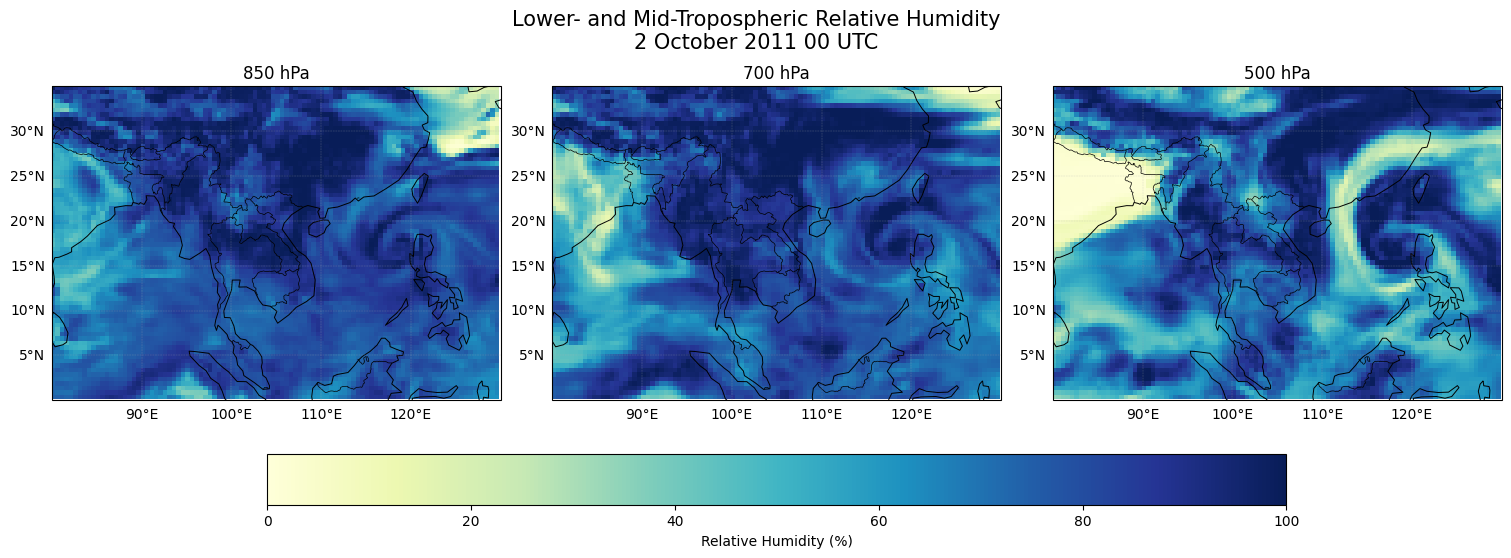

Saved: /content/drive/MyDrive/Teaching_ERA5_Reanalysis_GIS/04_figures/03/03_02_multilevel_relative_humidity.png


In [13]:
# CELL 13 — Multi-level relative humidity maps

RH_LEVELS = [
    850,
    700,
    500,
]

rh_fields = [
    subset_domain(
        event['r'].sel(level=level),
        ANALYSIS_DOMAIN,
    )
    for level in RH_LEVELS
]

fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(15, 5.5),
    subplot_kw={
        'projection': ccrs.PlateCarree()
    },
    constrained_layout=True,
)

for ax, level, field in zip(
    axes,
    RH_LEVELS,
    rh_fields,
):
    mesh = ax.pcolormesh(
        field['longitude'],
        field['latitude'],
        field,
        transform=ccrs.PlateCarree(),
        shading='auto',
        cmap='YlGnBu',
        vmin=0,
        vmax=100,
    )

    decorate_map(
        ax,
        extent=[
            ANALYSIS_DOMAIN['lon_min'],
            ANALYSIS_DOMAIN['lon_max'],
            ANALYSIS_DOMAIN['lat_min'],
            ANALYSIS_DOMAIN['lat_max'],
        ],
    )

    ax.set_title(
        f'{level} hPa'
    )

cbar = fig.colorbar(
    mesh,
    ax=axes.tolist(),
    orientation='horizontal',
    pad=0.08,
    shrink=0.82,
)

cbar.set_label('Relative Humidity (%)')

fig.suptitle(
    'Lower- and Mid-Tropospheric Relative Humidity\n'
    '2 October 2011 00 UTC',
    fontsize=15,
)

FIG_03_02 = (
    FIGURE_DIR
    / '03_02_multilevel_relative_humidity.png'
)

plt.savefig(
    FIG_03_02,
    dpi=300,
    bbox_inches='tight',
)

plt.show()

print('Saved:', FIG_03_02)

# 22. RH ไม่ใช่ Water-Vapor Mass โดยตรง

Relative humidity ขึ้นกับทั้ง water vapor และ temperature

ดังนั้น RH สูงไม่ได้แปลว่ามี absolute water vapor มากที่สุดเสมอ

specific humidity `q` เหมาะกับการอธิบาย water-vapor mass fraction โดยตรงกว่า

# 23. Figure 03-3 — Geopotential Height of Selected Pressure Surfaces

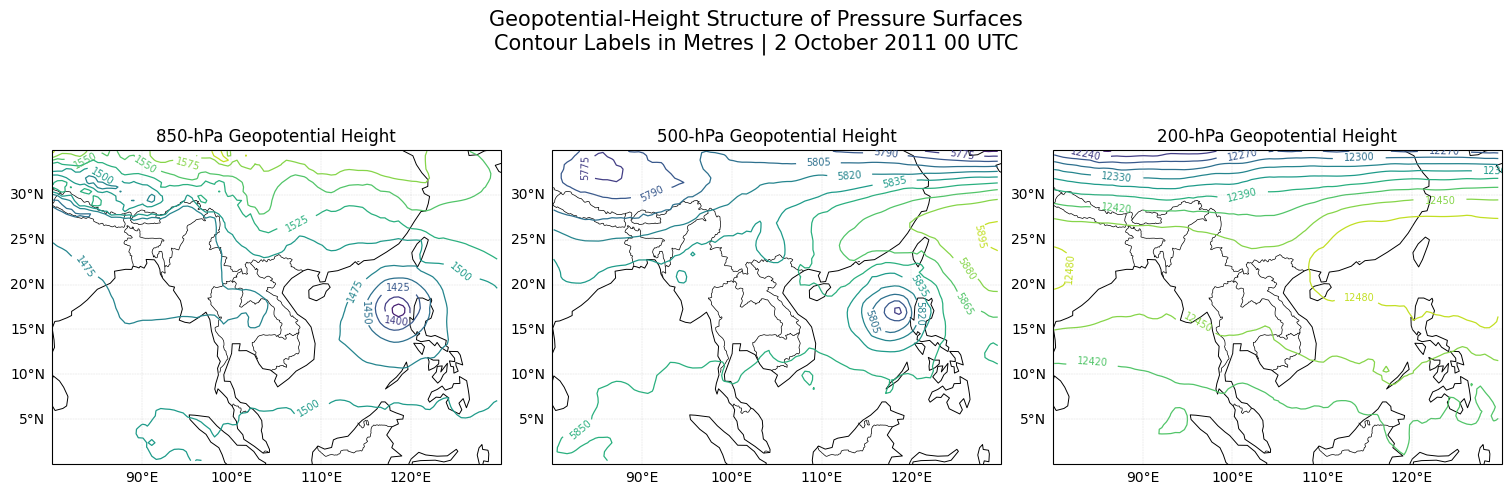

Saved: /content/drive/MyDrive/Teaching_ERA5_Reanalysis_GIS/04_figures/03/03_03_geopotential_height_pressure_surfaces.png


In [14]:
# CELL 14 — Geopotential-height maps

HEIGHT_LEVELS = [
    850,
    500,
    200,
]

height_fields = [
    subset_domain(
        geopotential_height_m.sel(level=level),
        ANALYSIS_DOMAIN,
    )
    for level in HEIGHT_LEVELS
]

fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(15, 5.5),
    subplot_kw={
        'projection': ccrs.PlateCarree()
    },
    constrained_layout=True,
)

for ax, level, field in zip(
    axes,
    HEIGHT_LEVELS,
    height_fields,
):
    contour = ax.contour(
        field['longitude'],
        field['latitude'],
        field,
        levels=10,
        transform=ccrs.PlateCarree(),
        linewidths=0.9,
    )

    ax.clabel(
        contour,
        inline=True,
        fontsize=7,
        fmt='%.0f',
    )

    decorate_map(
        ax,
        extent=[
            ANALYSIS_DOMAIN['lon_min'],
            ANALYSIS_DOMAIN['lon_max'],
            ANALYSIS_DOMAIN['lat_min'],
            ANALYSIS_DOMAIN['lat_max'],
        ],
    )

    ax.set_title(
        f'{level}-hPa Geopotential Height'
    )

fig.suptitle(
    'Geopotential-Height Structure of Pressure Surfaces\n'
    'Contour Labels in Metres | 2 October 2011 00 UTC',
    fontsize=15,
)

FIG_03_03 = (
    FIGURE_DIR
    / '03_03_geopotential_height_pressure_surfaces.png'
)

plt.savefig(
    FIG_03_03,
    dpi=300,
    bbox_inches='tight',
)

plt.show()

print('Saved:', FIG_03_03)

# 24. Geopotential Height เป็น Synoptic Variable สำคัญ

pressure surface เดียวกันมี height ต่างกันตามพื้นที่

geopotential-height contours ช่วยให้เห็น large-scale pressure-surface geometry และจะนำไปใช้ต่อในการอ่าน ridges, troughs และ circulation ใน Notebook 05

# 25. ตำแหน่งตัวอย่างสำหรับ Vertical Profiles

In [15]:
# CELL 15 — Example locations

LOCATIONS = {
    'Bangkok': {
        'latitude': 13.7563,
        'longitude': 100.5018,
    },
    'Chiang Mai': {
        'latitude': 18.7883,
        'longitude': 98.9853,
    },
    'Nakhon Ratchasima': {
        'latitude': 14.9799,
        'longitude': 102.0977,
    },
}

LOCATIONS_DF = pd.DataFrame(
    [
        {
            'location': name,
            **coords,
        }
        for name, coords in LOCATIONS.items()
    ]
)

display(LOCATIONS_DF)

,location,latitude,longitude
0,Bangkok,13.7563,100.5018
1,Chiang Mai,18.7883,98.9853
2,Nakhon Ratchasima,14.9799,102.0977


# 26. การสร้าง Vertical Profile

ถ้าเลือก latitude และ longitude แต่ไม่เลือก `level` จะเหลือ vertical dimension เป็น pressure

```text
4-D field
→ select time
→ select location
→ 1-D vertical profile
```

In [16]:
# CELL 16 — Extract vertical profiles

profile_rows = []

for location_name, coords in LOCATIONS.items():
    temp_profile_K = event['t'].sel(
        latitude=coords['latitude'],
        longitude=coords['longitude'],
        method='nearest',
    )

    rh_profile = event['r'].sel(
        latitude=coords['latitude'],
        longitude=coords['longitude'],
        method='nearest',
    )

    q_profile_gkg = (
        event['q'].sel(
            latitude=coords['latitude'],
            longitude=coords['longitude'],
            method='nearest',
        )
        * 1000.0
    )

    h_profile_m = (
        event['z'].sel(
            latitude=coords['latitude'],
            longitude=coords['longitude'],
            method='nearest',
        )
        / G0
    )

    for index, level in enumerate(
        temp_profile_K['level'].values
    ):
        temperature_value_K = float(
            temp_profile_K.isel(level=index).values
        )

        theta_value_K = (
            temperature_value_K
            * (
                1000.0
                / float(level)
            ) ** KAPPA
        )

        profile_rows.append(
            {
                'location': location_name,
                'pressure_hPa': float(level),
                'temperature_C': temperature_value_K - 273.15,
                'relative_humidity_pct': float(
                    rh_profile.isel(level=index).values
                ),
                'specific_humidity_gkg': float(
                    q_profile_gkg.isel(level=index).values
                ),
                'geopotential_height_m': float(
                    h_profile_m.isel(level=index).values
                ),
                'potential_temperature_K': theta_value_K,
                'selected_grid_latitude': float(
                    temp_profile_K['latitude'].values
                ),
                'selected_grid_longitude': float(
                    temp_profile_K['longitude'].values
                ),
            }
        )

VERTICAL_PROFILES = pd.DataFrame(
    profile_rows
)

display(
    VERTICAL_PROFILES.head(12)
)

,location,pressure_hPa,temperature_C,relative_humidity_pct,specific_humidity_gkg,geopotential_height_m,potential_temperature_K,selected_grid_latitude,selected_grid_longitude
0,Bangkok,200.0,-51.727362,93.325623,0.092089,12447.875977,350.801951,13.875,100.625
1,Bangkok,250.0,-39.567053,102.155159,0.343365,10960.536133,347.195368,13.875,100.625
2,Bangkok,300.0,-29.741049,100.830406,0.818506,9688.035156,343.424212,13.875,100.625
3,Bangkok,500.0,-4.543616,66.963882,3.606040,5847.749512,327.478450,13.875,100.625
4,Bangkok,700.0,9.466608,99.094765,10.454181,3119.534180,312.957336,13.875,100.625
5,Bangkok,850.0,17.578577,77.521332,11.475976,1481.555786,304.556099,13.875,100.625
6,Bangkok,925.0,22.288690,71.395393,13.022980,750.651001,302.097870,13.875,100.625
7,Bangkok,1000.0,25.429742,79.959595,16.302998,66.361366,298.579742,13.875,100.625
8,Chiang Mai,200.0,-51.654410,103.888214,0.104396,12466.262695,350.917530,18.875,99.125
9,Chiang Mai,250.0,-38.777502,89.662422,0.327794,10978.272461,348.368948,18.875,99.125


# 27. Figure 03-4 — Temperature and Relative-Humidity Vertical Profiles

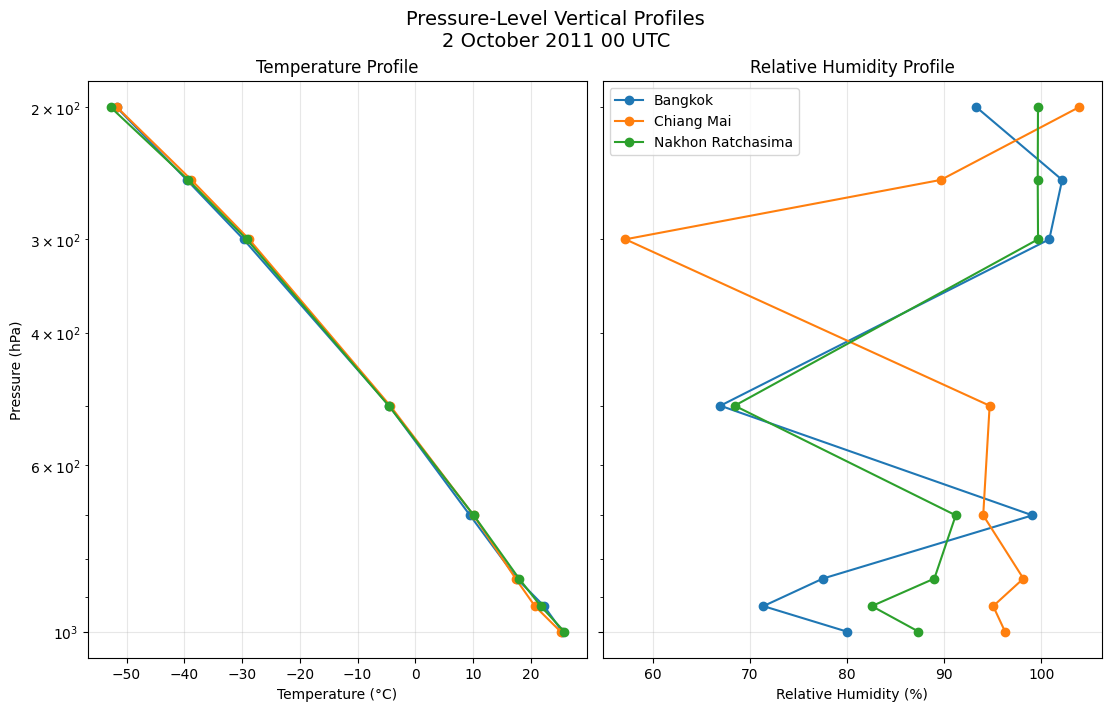

Saved: /content/drive/MyDrive/Teaching_ERA5_Reanalysis_GIS/04_figures/03/03_04_temperature_RH_vertical_profiles.png


In [17]:
# CELL 17 — Temperature and RH vertical profiles

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(11, 7),
    sharey=True,
    constrained_layout=True,
)

for location_name, group in VERTICAL_PROFILES.groupby('location'):
    group = group.sort_values(
        'pressure_hPa',
        ascending=False,
    )

    axes[0].plot(
        group['temperature_C'],
        group['pressure_hPa'],
        marker='o',
        label=location_name,
    )

    axes[1].plot(
        group['relative_humidity_pct'],
        group['pressure_hPa'],
        marker='o',
        label=location_name,
    )

for ax in axes:
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)

axes[0].invert_yaxis()

axes[0].set_xlabel('Temperature (°C)')
axes[0].set_ylabel('Pressure (hPa)')
axes[0].set_title('Temperature Profile')

axes[1].set_xlabel('Relative Humidity (%)')
axes[1].set_title('Relative Humidity Profile')
axes[1].legend(loc='best')

fig.suptitle(
    'Pressure-Level Vertical Profiles\n'
    '2 October 2011 00 UTC',
    fontsize=14,
)

FIG_03_04 = (
    FIGURE_DIR
    / '03_04_temperature_RH_vertical_profiles.png'
)

plt.savefig(
    FIG_03_04,
    dpi=300,
    bbox_inches='tight',
)

plt.show()

print('Saved:', FIG_03_04)

# 28. ทำไม Pressure Axis จึง Invert?

vertical atmospheric plots นิยมให้ high pressure อยู่ด้านล่าง และ low pressure อยู่ด้านบน เพื่อเลียนแบบ orientation จริงของบรรยากาศ

# 29. Figure 03-5 — Specific Humidity and Geopotential-Height Profiles

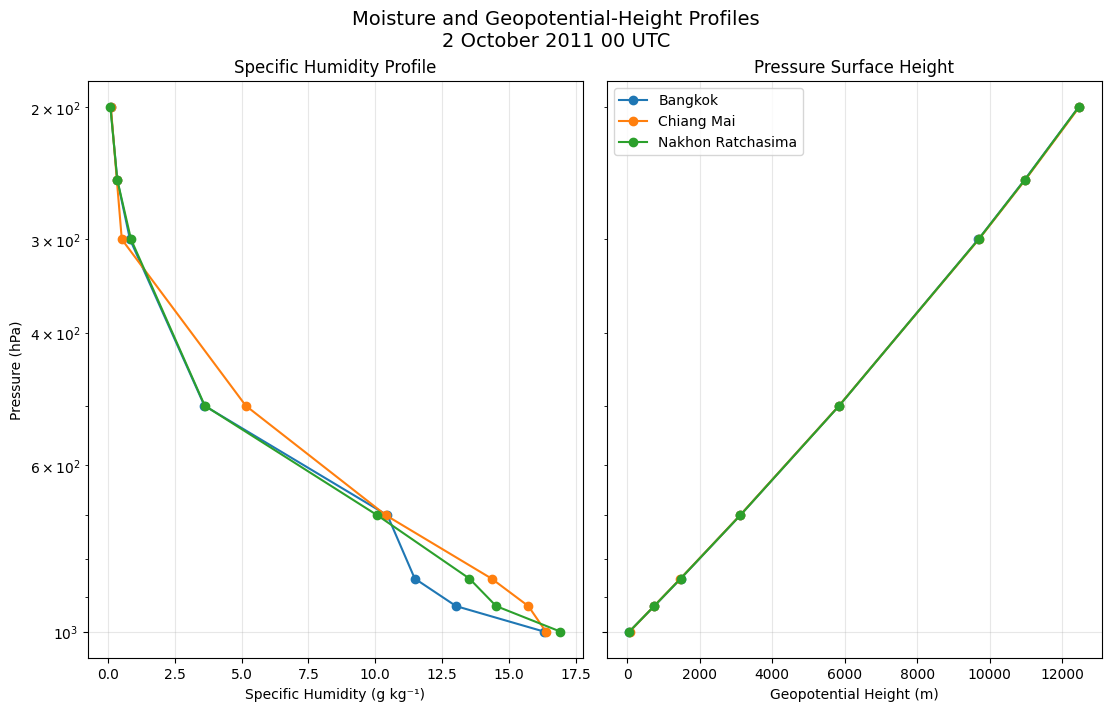

Saved: /content/drive/MyDrive/Teaching_ERA5_Reanalysis_GIS/04_figures/03/03_05_specific_humidity_geopotential_height_profiles.png


In [18]:
# CELL 18 — Specific humidity and height profiles

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(11, 7),
    sharey=True,
    constrained_layout=True,
)

for location_name, group in VERTICAL_PROFILES.groupby('location'):
    group = group.sort_values(
        'pressure_hPa',
        ascending=False,
    )

    axes[0].plot(
        group['specific_humidity_gkg'],
        group['pressure_hPa'],
        marker='o',
        label=location_name,
    )

    axes[1].plot(
        group['geopotential_height_m'],
        group['pressure_hPa'],
        marker='o',
        label=location_name,
    )

for ax in axes:
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)

axes[0].invert_yaxis()

axes[0].set_xlabel('Specific Humidity (g kg⁻¹)')
axes[0].set_ylabel('Pressure (hPa)')
axes[0].set_title('Specific Humidity Profile')

axes[1].set_xlabel('Geopotential Height (m)')
axes[1].set_title('Pressure Surface Height')
axes[1].legend(loc='best')

fig.suptitle(
    'Moisture and Geopotential-Height Profiles\n'
    '2 October 2011 00 UTC',
    fontsize=14,
)

FIG_03_05 = (
    FIGURE_DIR
    / '03_05_specific_humidity_geopotential_height_profiles.png'
)

plt.savefig(
    FIG_03_05,
    dpi=300,
    bbox_inches='tight',
)

plt.show()

print('Saved:', FIG_03_05)

# 30. Figure 03-6 — Potential Temperature Profiles

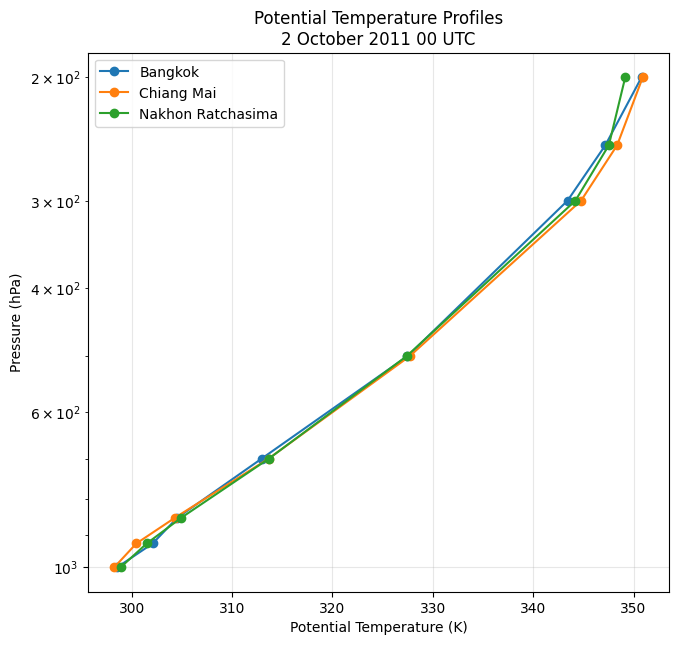

Saved: /content/drive/MyDrive/Teaching_ERA5_Reanalysis_GIS/04_figures/03/03_06_potential_temperature_profiles.png


In [19]:
# CELL 19 — Potential temperature profiles

fig, ax = plt.subplots(
    figsize=(7.5, 7)
)

for location_name, group in VERTICAL_PROFILES.groupby('location'):
    group = group.sort_values(
        'pressure_hPa',
        ascending=False,
    )

    ax.plot(
        group['potential_temperature_K'],
        group['pressure_hPa'],
        marker='o',
        label=location_name,
    )

ax.set_yscale('log')
ax.invert_yaxis()
ax.set_xlabel('Potential Temperature (K)')
ax.set_ylabel('Pressure (hPa)')
ax.set_title(
    'Potential Temperature Profiles\n'
    '2 October 2011 00 UTC'
)
ax.grid(True, alpha=0.3)
ax.legend()

FIG_03_06 = (
    FIGURE_DIR
    / '03_06_potential_temperature_profiles.png'
)

plt.savefig(
    FIG_03_06,
    dpi=300,
    bbox_inches='tight',
)

plt.show()

print('Saved:', FIG_03_06)

# 31. Interpretation ของ Potential Temperature

ถ้า $\theta$ เพิ่มขึ้นเมื่อ pressure ลดลง โดยทั่วไปสัมพันธ์กับ stable stratification

แต่ต้องระวังว่า pressure-level spacing ค่อนข้างหยาบ และไม่ควรใช้แทน radiosonde สำหรับวิเคราะห์ shallow inversion หรือ boundary-layer detail

# 32. Pressure-Surface Height Range over the Regional Domain

In [20]:
# CELL 20 — Height range of selected pressure surfaces

height_range_rows = []

for level in [
    850,
    700,
    500,
    300,
    200,
]:
    field = subset_domain(
        geopotential_height_m.sel(level=level),
        ANALYSIS_DOMAIN,
    )

    minimum = float(field.min().values)
    mean = float(field.mean().values)
    maximum = float(field.max().values)

    height_range_rows.append(
        {
            'pressure_hPa': level,
            'minimum_height_m': minimum,
            'mean_height_m': mean,
            'maximum_height_m': maximum,
            'spatial_range_m': maximum - minimum,
        }
    )

PRESSURE_SURFACE_HEIGHT_RANGE = pd.DataFrame(
    height_range_rows
)

display(PRESSURE_SURFACE_HEIGHT_RANGE)

,pressure_hPa,minimum_height_m,mean_height_m,maximum_height_m,spatial_range_m
0,850,1355.050171,1499.762573,1620.602051,265.551880
1,700,3007.917480,3129.489990,3186.234619,178.317139
2,500,5758.665527,5841.321777,5899.011230,140.345703
3,300,9487.534180,9672.551758,9738.147461,250.613281
4,200,12208.555664,12428.805664,12508.231445,299.675781


ตารางนี้ยืนยันจากข้อมูลจริงว่า pressure surface เดียวกันไม่ได้อยู่ที่ความสูงคงที่ทุกตำแหน่ง

# 33. Export Vertical-Structure Tables

In [21]:
# CELL 21 — Export tables

VERTICAL_PROFILE_CSV = (
    OUTPUT_DIR
    / '03_vertical_profiles_selected_locations.csv'
)

HEIGHT_RANGE_CSV = (
    OUTPUT_DIR
    / '03_pressure_surface_height_range.csv'
)

PRESSURE_LEVEL_CSV = (
    METADATA_DIR
    / '03_pressure_level_inventory.csv'
)

VERTICAL_PROFILES.to_csv(
    VERTICAL_PROFILE_CSV,
    index=False,
)

PRESSURE_SURFACE_HEIGHT_RANGE.to_csv(
    HEIGHT_RANGE_CSV,
    index=False,
)

PRESSURE_LEVEL_AUDIT.to_csv(
    PRESSURE_LEVEL_CSV,
    index=False,
)

print('Saved:', VERTICAL_PROFILE_CSV)
print('Saved:', HEIGHT_RANGE_CSV)
print('Saved:', PRESSURE_LEVEL_CSV)

Saved: /content/drive/MyDrive/Teaching_ERA5_Reanalysis_GIS/03_output/03_vertical_profiles_selected_locations.csv
Saved: /content/drive/MyDrive/Teaching_ERA5_Reanalysis_GIS/03_output/03_pressure_surface_height_range.csv
Saved: /content/drive/MyDrive/Teaching_ERA5_Reanalysis_GIS/02_metadata/03_pressure_level_inventory.csv


# 34. Figure Manifest

In [22]:
# CELL 22 — Figure manifest

FIGURE_MANIFEST = pd.DataFrame(
    [
        {
            'figure': '03-01',
            'file': str(FIG_03_01),
            'description': 'Multi-level temperature structure',
        },
        {
            'figure': '03-02',
            'file': str(FIG_03_02),
            'description': 'Relative humidity at 850, 700 and 500 hPa',
        },
        {
            'figure': '03-03',
            'file': str(FIG_03_03),
            'description': 'Geopotential-height contours for selected pressure surfaces',
        },
        {
            'figure': '03-04',
            'file': str(FIG_03_04),
            'description': 'Temperature and RH vertical profiles',
        },
        {
            'figure': '03-05',
            'file': str(FIG_03_05),
            'description': 'Specific-humidity and geopotential-height profiles',
        },
        {
            'figure': '03-06',
            'file': str(FIG_03_06),
            'description': 'Potential-temperature profiles',
        },
    ]
)

FIGURE_MANIFEST_CSV = (
    METADATA_DIR
    / '03_figure_manifest.csv'
)

FIGURE_MANIFEST.to_csv(
    FIGURE_MANIFEST_CSV,
    index=False,
)

display(FIGURE_MANIFEST)

,figure,file,description
0,03-01,/content/drive/MyDrive/Teaching_ERA5_Reanalysi...,Multi-level temperature structure
1,03-02,/content/drive/MyDrive/Teaching_ERA5_Reanalysi...,"Relative humidity at 850, 700 and 500 hPa"
2,03-03,/content/drive/MyDrive/Teaching_ERA5_Reanalysi...,Geopotential-height contours for selected pres...
3,03-04,/content/drive/MyDrive/Teaching_ERA5_Reanalysi...,Temperature and RH vertical profiles
4,03-05,/content/drive/MyDrive/Teaching_ERA5_Reanalysi...,Specific-humidity and geopotential-height prof...
5,03-06,/content/drive/MyDrive/Teaching_ERA5_Reanalysi...,Potential-temperature profiles


# 35. Common Mistakes

1. คิดว่า `850 hPa = 1,500 m` เสมอ
2. ใช้ ERA5 `z` แล้วเรียกหน่วยว่า metres โดยไม่หารด้วย $g_0$
3. คิดว่า RH สูงหมายถึง specific humidity สูงเสมอ
4. ใช้ 1000 หรือ 925 hPa เหนือภูเขาสูงโดยไม่ระวัง below-ground pressure surface
5. ตีความ pressure-level profile เป็น high-resolution radiosonde
6. คิดว่า potential temperature เท่ากับ actual temperature

# 36. Exercises

### Exercise 1 — Temperature Structure
เลือก location หนึ่งและรายงาน temperature ที่ 1000, 850, 700, 500, 300 และ 200 hPa

### Exercise 2 — Pressure-Surface Height
รายงาน geopotential height ของ 850, 500 และ 200 hPa

### Exercise 3 — Moisture
เปรียบเทียบ RH และ specific humidity ที่ 850 และ 500 hPa

### Exercise 4 — Potential Temperature
คำนวณ $\theta$ ที่ 850 และ 500 hPa

### Exercise 5 — Geographic Comparison
เลือกสองจังหวัดแล้วเปรียบเทียบ vertical profiles

### Exercise 6 — Scientific Interpretation
อธิบายประโยค:

> **A pressure level is not a fixed geometric height surface.**

# 37. Final Readiness Check

In [23]:
# CELL 23 — Final readiness

readiness_rows = []


def add_check(
    item,
    passed,
    note='',
):
    readiness_rows.append(
        {
            'item': item,
            'status': 'PASS' if passed else 'FAIL',
            'note': note,
        }
    )

required_levels = {
    1000,
    850,
    700,
    500,
    300,
    200,
}

available_levels = set(
    int(value)
    for value in np.atleast_1d(
        ds['level'].values
    )
)

add_check(
    'EVENT dataset opened',
    isinstance(ds, xr.Dataset),
)

add_check(
    'Required pressure levels available',
    required_levels.issubset(available_levels),
)

for variable_name in [
    't',
    'r',
    'q',
    'z',
]:
    add_check(
        f'{variable_name} available',
        variable_name in ds.data_vars,
    )

for figure_path, figure_name in [
    (FIG_03_01, 'Multi-level temperature figure'),
    (FIG_03_02, 'Relative-humidity figure'),
    (FIG_03_03, 'Geopotential-height figure'),
    (FIG_03_04, 'Temperature/RH profile figure'),
    (FIG_03_05, 'Moisture/height profile figure'),
    (FIG_03_06, 'Potential-temperature figure'),
]:
    add_check(
        f'{figure_name} exported',
        figure_path.exists(),
    )

add_check(
    'Vertical-profile CSV exported',
    VERTICAL_PROFILE_CSV.exists(),
)

add_check(
    'Pressure-surface height CSV exported',
    HEIGHT_RANGE_CSV.exists(),
)

READINESS = pd.DataFrame(
    readiness_rows
)

display(READINESS)

ALL_READY = bool(
    (
        READINESS['status']
        == 'PASS'
    ).all()
)

READINESS_CSV = (
    METADATA_DIR
    / '03_readiness_check.csv'
)

READINESS.to_csv(
    READINESS_CSV,
    index=False,
)

print()

if ALL_READY:
    print('NOTEBOOK 03 READY')
    print('Next: Notebook 04 — Wind and Vector Analysis')
else:
    print('NOTEBOOK 03 REQUIRES REVIEW')

,item,status,note
0,EVENT dataset opened,PASS,
1,Required pressure levels available,PASS,
2,t available,PASS,
3,r available,PASS,
4,q available,PASS,
5,z available,PASS,
6,Multi-level temperature figure exported,PASS,
7,Relative-humidity figure exported,PASS,
8,Geopotential-height figure exported,PASS,
9,Temperature/RH profile figure exported,PASS,



NOTEBOOK 03 READY
Next: Notebook 04 — Wind and Vector Analysis


# 38. สิ่งที่ต้องจำจาก Notebook 03

```text
Pressure
→ decreases with height

pressure level
≠ fixed geometric height

ERA5 z
→ geopotential

z / g0
→ geopotential height

RH
≠ water-vapor mass directly

specific humidity
→ water-vapor mass fraction

potential temperature
→ useful thermodynamic vertical coordinate

pressure-level profile
≠ high-resolution sounding

low-level pressure surfaces over mountains
→ require caution
```

> **บรรยากาศเป็นระบบสามมิติ การอ่านแผนที่เพียงระดับเดียวอาจไม่เพียงพอต่อการอธิบาย atmospheric process**

# Course Progress

```text
00  Download & Data Audit        ✓
 ↓
01  NetCDF & Xarray Fundamentals ✓
 ↓
02  Spatial Subsetting & Cartopy ✓
 ↓
03  Pressure-Level Structure     ✓
 ↓
04  Wind & Vector Analysis
 ↓
05  Synoptic Weather Maps & Dynamics
 ↓
06  Hovmöller & Spatiotemporal Analysis
 ↓
07  Climatology
 ↓
08  Anomaly
 ↓
09  Integrated Noul 2011 Case Study
```